In [11]:
import os
import numpy as np
import pandas as pd
from TSB_UAD.utils.visualisation import plotFig
from TSB_UAD.models.iforest import IForest
from TSB_UAD.models.AE import AE_MLP2
from TSB_UAD.models.distance import Fourier
from TSB_UAD.models.lstm import lstm
from TSB_UAD.models.feature import Window
from TSB_UAD.utils.slidingWindows import find_length
from TSB_UAD.vus.metrics import get_metrics
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import math

%matplotlib widget

### Carga de datos

In [ ]:

path_train = "./train.csv"
path_test = "./test.csv"
path_sample_submission = "./sample_submission_scores.csv"

datos_train = pd.read_csv(path_train)
datos_test = pd.read_csv(path_test)
datos_sample_submission = pd.read_csv(path_sample_submission)

datos_train["timestamp"] = pd.to_datetime(datos_train["timestamp"])
datos_test["timestamp"] = pd.to_datetime(datos_test["timestamp"])

print(datos_train.head())
print(datos_test.head())

total = len(datos_train)
anomalias_s1 = datos_train["label1"].sum()
porcentaje_anomalias_s1 = (anomalias_s1/total)*100
print(f"Porcentaje anomalias serie 1 : {porcentaje_anomalias_s1:.2f}%")

anomalias_s2 = datos_train["label2"].sum()
porcentaje_anomalias_s2 = (anomalias_s2/total)*100
print(f"Porcentaje anomalias serie 2 : {porcentaje_anomalias_s2:.2f}%")

anomalias_s3 = datos_train["label3"].sum()
porcentaje_anomalias_s3 = (anomalias_s3/total)*100
print(f"Porcentaje anomalias serie 3 : {porcentaje_anomalias_s3:.2f}%")

anomalias_s4 = datos_train["label4"].sum()
porcentaje_anomalias_s4 = (anomalias_s4/total)*100
print(f"Porcentaje anomalias serie 4 : {porcentaje_anomalias_s4:.2f}%")

            timestamp  serie1  label1  serie2  label2     serie3  label3  \
0 2022-01-01 01:00:00  3.2436     1.0   1.728     0.0  11.187799     0.0   
1 2022-01-01 02:00:00  3.4650     1.0   1.824     0.0  11.086999     0.0   
2 2022-01-01 03:00:00  3.4650     1.0   1.824     0.0  10.078000     0.0   
3 2022-01-01 04:00:00  3.5388     1.0   1.824     0.0   9.297799     0.0   
4 2022-01-01 05:00:00  3.3912     1.0   1.728     0.0   8.315000     0.0   

     serie4  label4  
0  4.064000     0.0  
1  4.112000     0.0  
2  4.280000     0.0  
3  4.269001     1.0  
4  4.064000     1.0  
            timestamp  serie1  serie2    serie3  serie4
0 2024-01-01 01:00:00   2.212   1.353  9.467999   2.854
1 2024-01-01 02:00:00   2.182   1.329  8.664001   2.748
2 2024-01-01 03:00:00   2.046   1.263  7.799000   2.660
3 2024-01-01 04:00:00   1.908   1.235  7.638000   2.622
4 2024-01-01 05:00:00   1.791   1.129  6.499000   2.544
Porcentaje anomalias serie 1 : 1.45%
Porcentaje anomalias serie 2 : 2.33%
P

### Visualizacion de las series

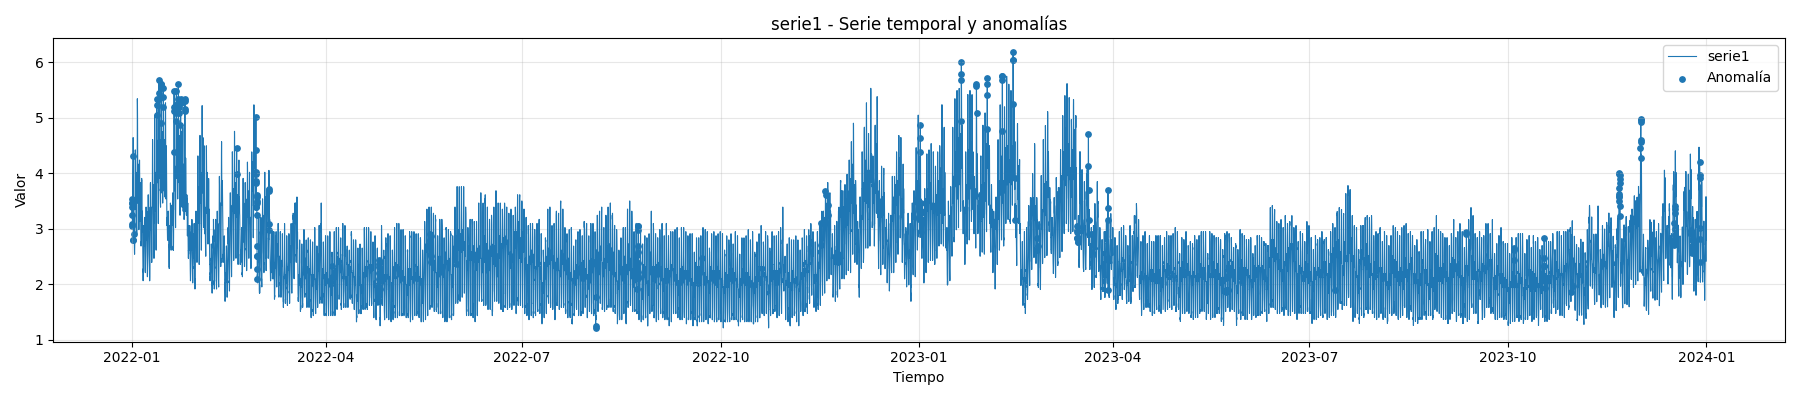

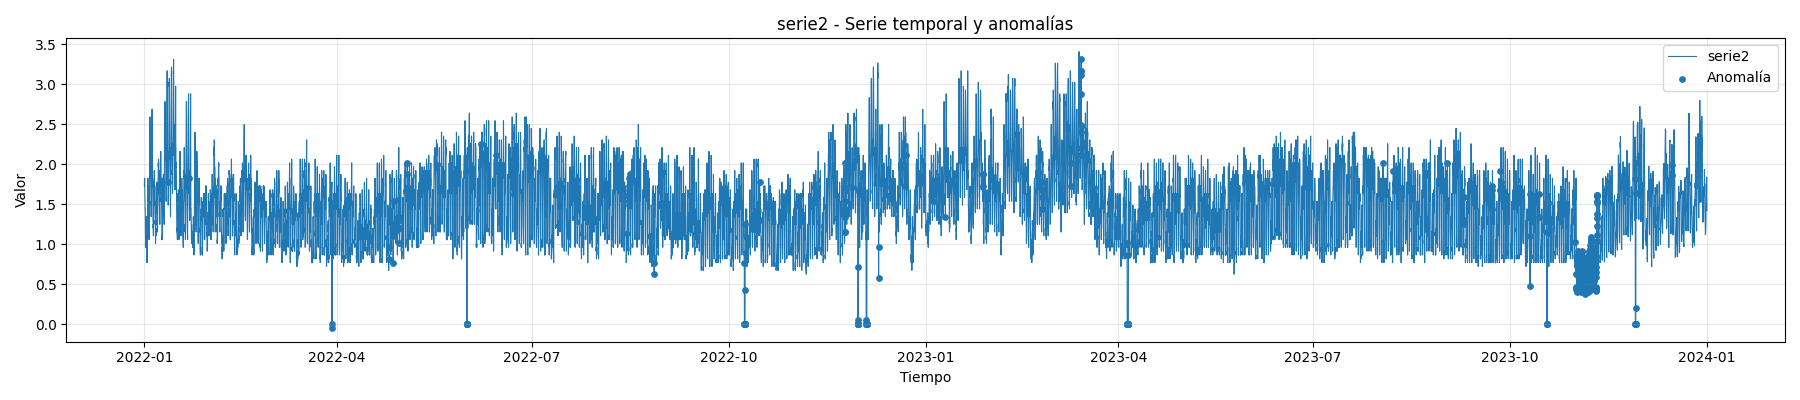

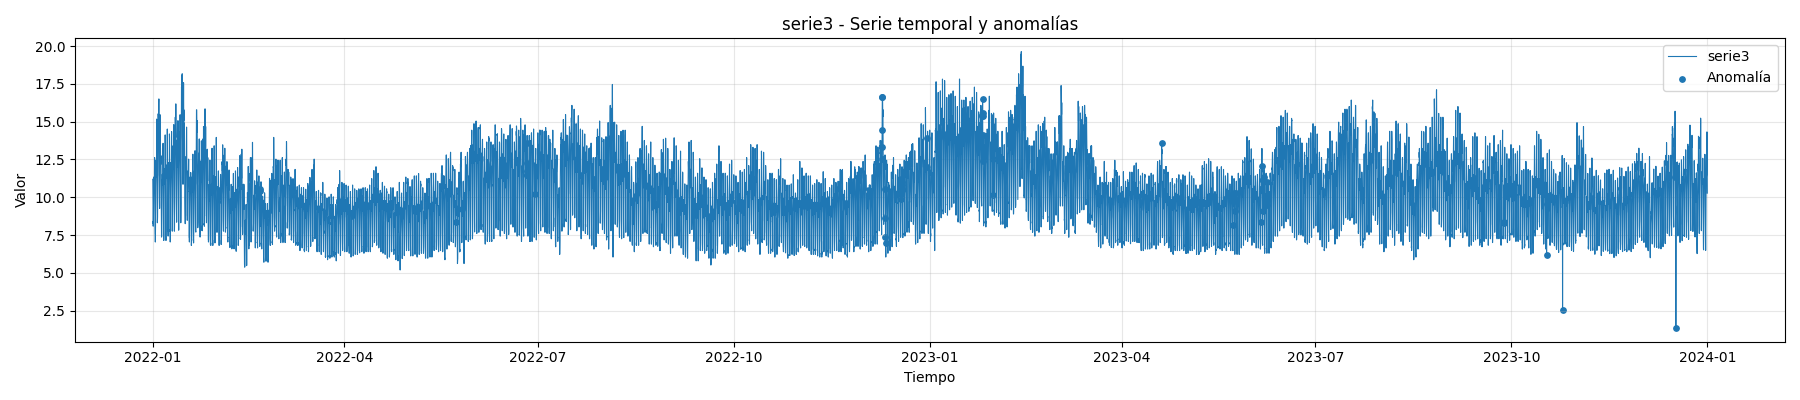

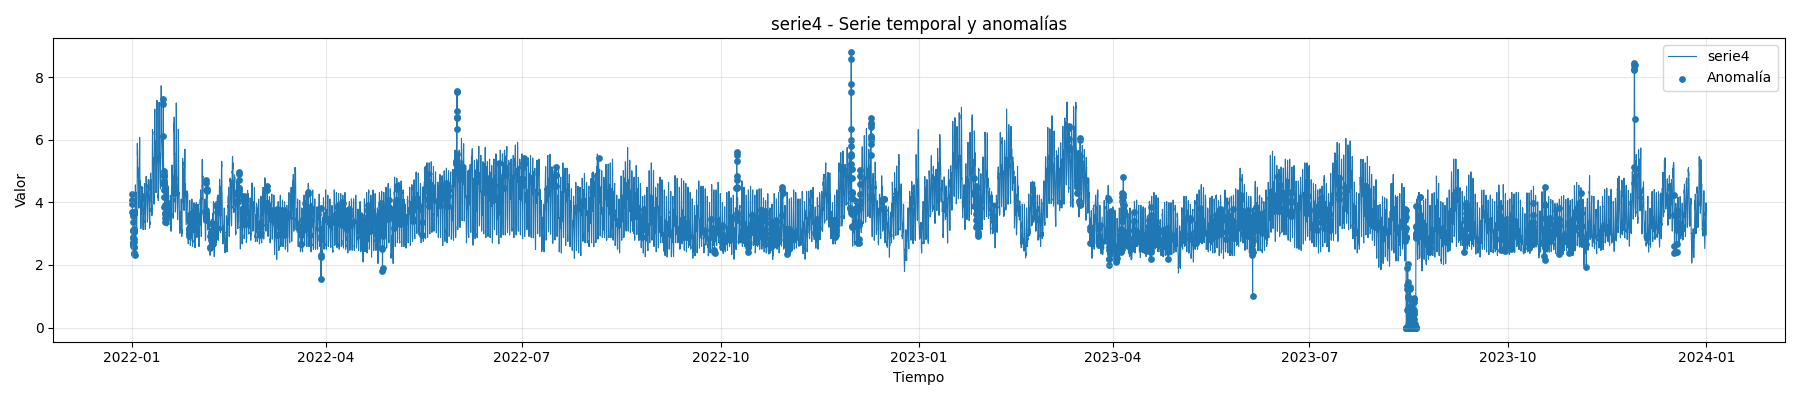

In [10]:
import matplotlib.pyplot as plt

%matplotlib widget

series = ["serie1", "serie2", "serie3", "serie4"]

for serie in series:
    
    label = serie.replace("serie", "label")
    
    plt.figure(figsize=(18, 4))
    
    # Serie temporal
    plt.plot(
        datos_train["timestamp"],
        datos_train[serie],
        linewidth=0.8,
        label=serie
    )
    
    # Anomalías
    anomalías = datos_train[label] == 1
    
    plt.scatter(
        datos_train.loc[anomalías, "timestamp"],
        datos_train.loc[anomalías, serie],
        s=15,
        label="Anomalía"
    )
    
    plt.title(f"{serie} - Serie temporal y anomalías")
    plt.xlabel("Tiempo")
    plt.ylabel("Valor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Procesando serie1
Sliding window: 24

Métricas para serie1:
AUC_ROC: 0.7907502889024081
AUC_PR: 0.06138110809739415
Precision: 0.07961165048543689
Recall: 0.16141732283464566
F: 0.10663198959687907
Precision_at_k: 0.16141732283464566
Rprecision: 0.05069003069003069
Rrecall: 0.19432234432234433
RF: 0.08040578029547146
R_AUC_ROC: 0.8403898349948744
R_AUC_PR: 0.2474134708247474
VUS_ROC: 0.8165655325995584
VUS_PR: 0.18092496811795453
Affiliation_Precision: 0.60860926091333
Affiliation_Recall: 0.47907816769628586

Procesando serie2
Sliding window: 24

Métricas para serie2:
AUC_ROC: 0.8738155683892845
AUC_PR: 0.29178501424381936
Precision: 0.31675392670157065
Recall: 0.29584352078239606
F: 0.3059418457648546
Precision_at_k: 0.29584352078239606
Rprecision: 0.19988390092879255
Rrecall: 0.06309556819360741
RF: 0.09591462287108751
R_AUC_ROC: 0.8010097329472917
R_AUC_PR: 0.2320452766580406
VUS_ROC: 0.7639907340012548
VUS_PR: 0.1960870493556702
Affiliation_Precision: 0.6695789280691432
Affiliatio

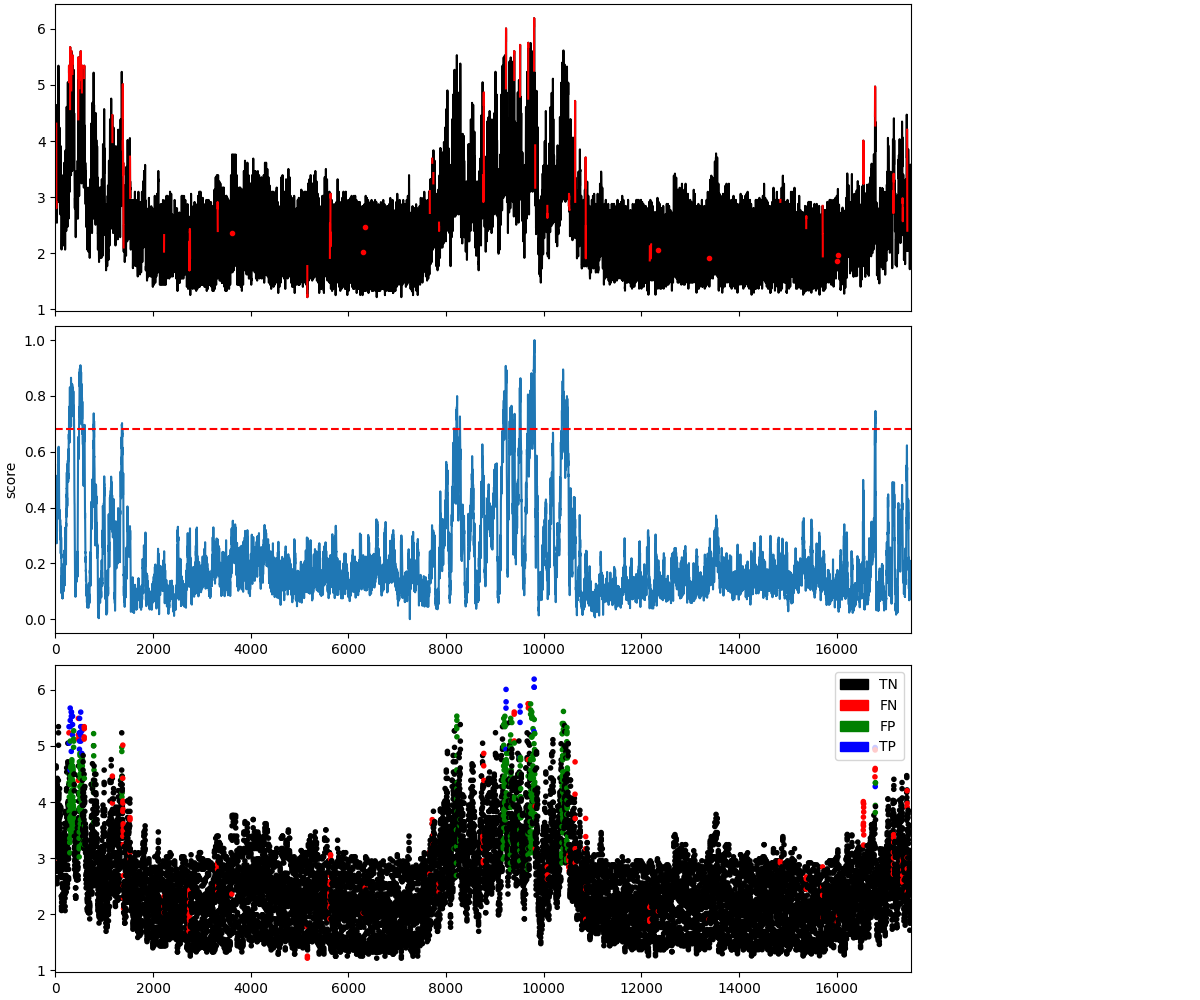

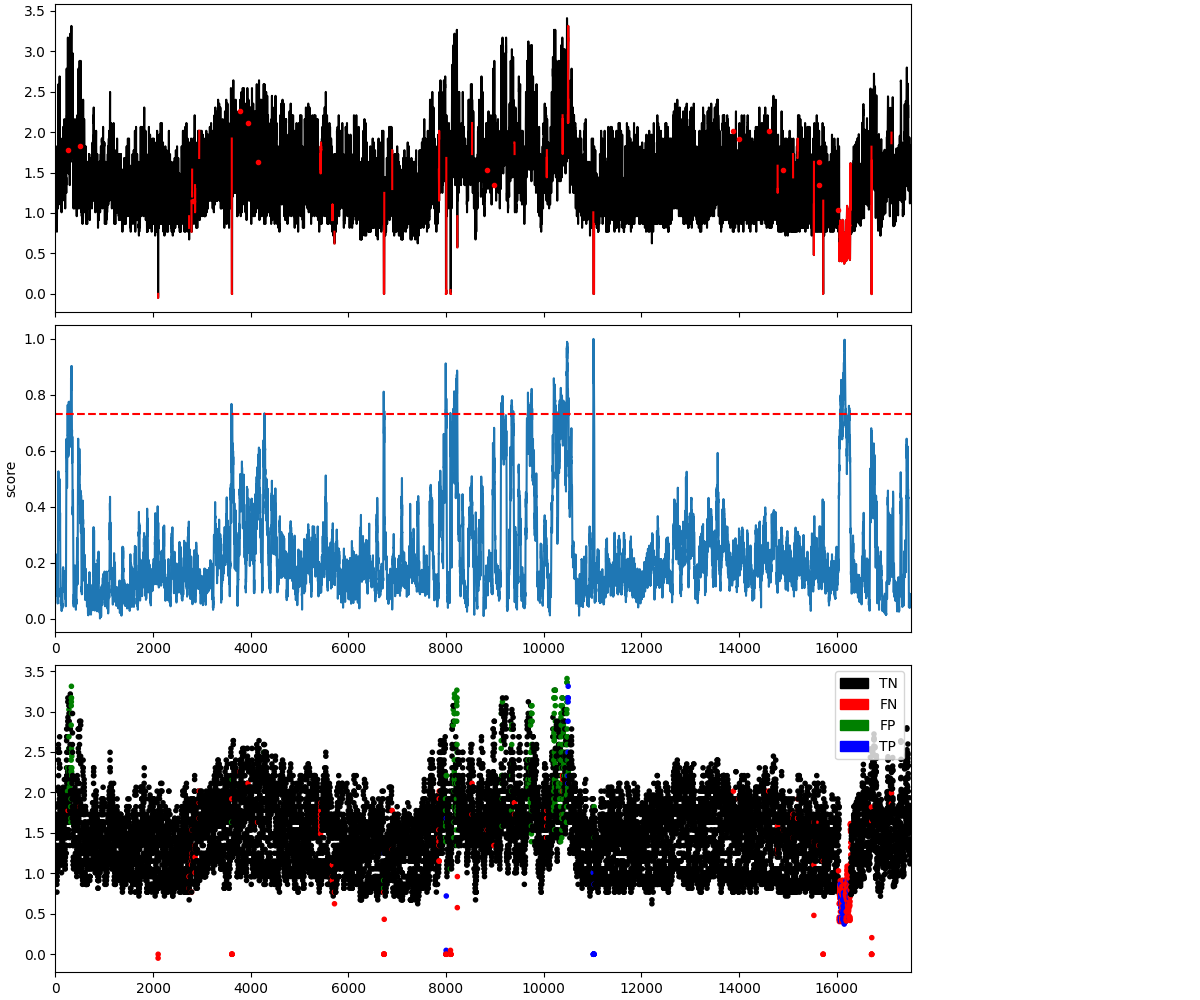

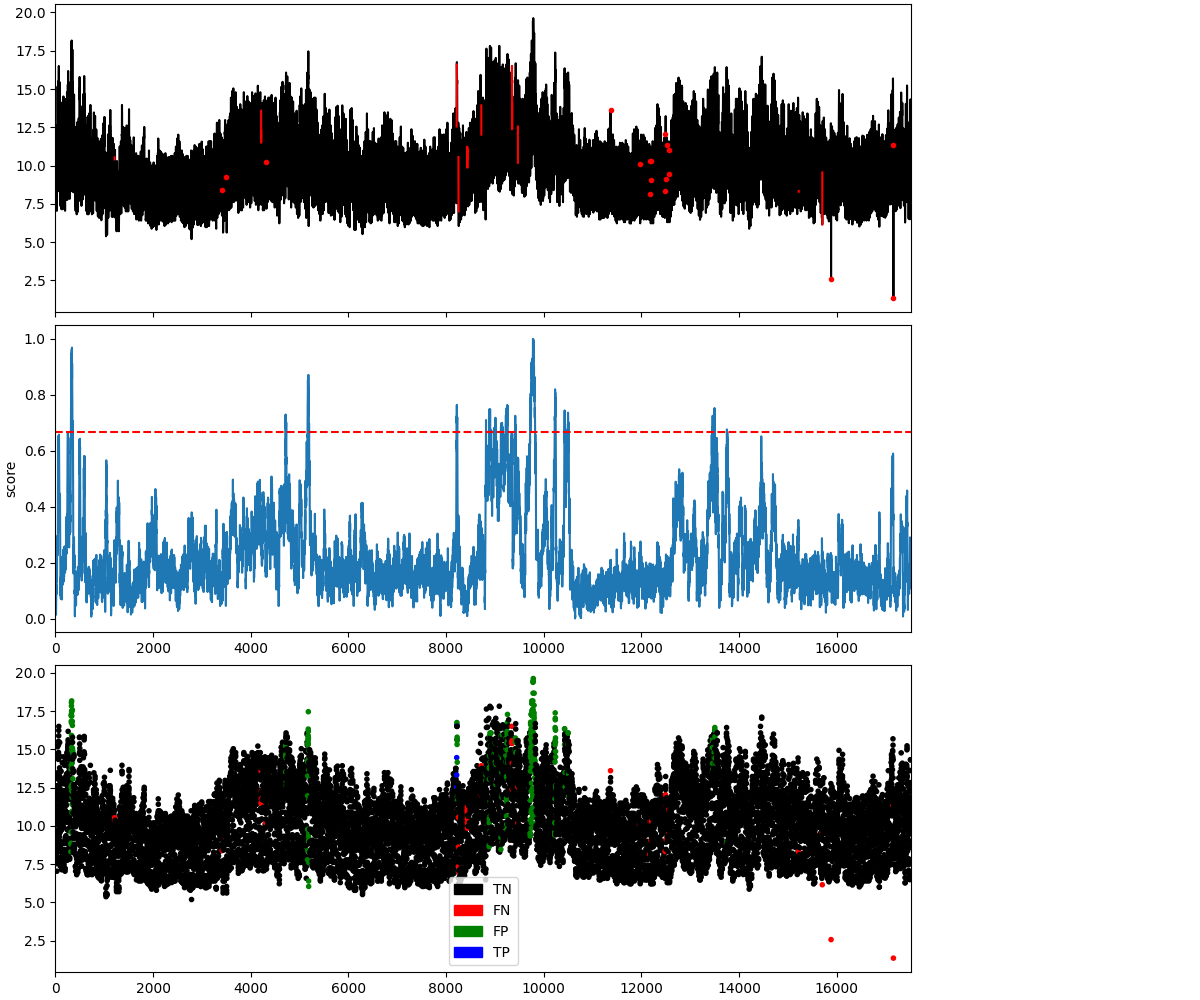

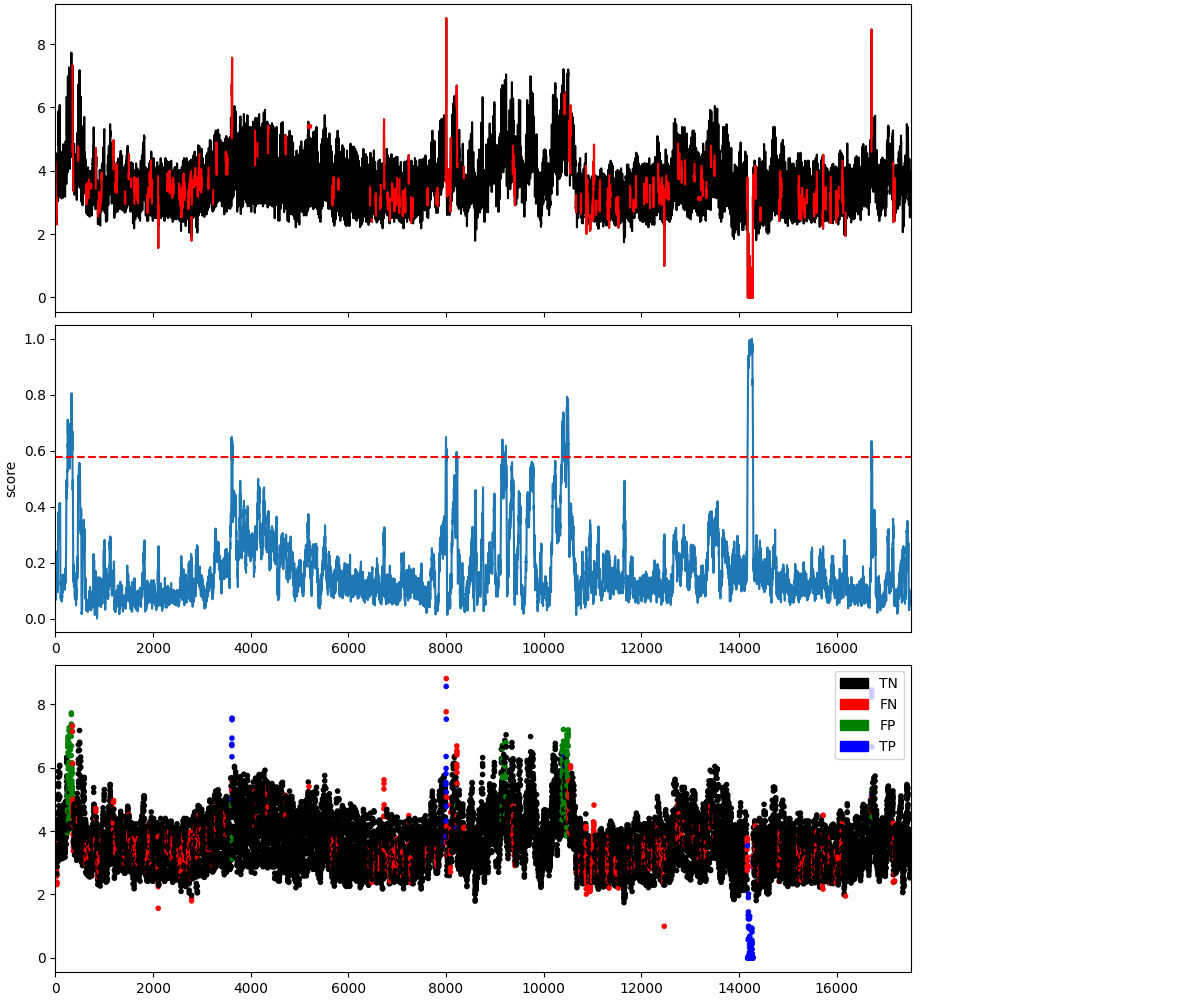

In [24]:
series = ["serie1", "serie2", "serie3", "serie4"]
model_name = "LSTM"
models = {}
scalers = {}
scores = {}
windows = {}

for serie in series:

    print(f"\nProcesando {serie}")

    # -------------------------------------------------
    # 1. Datos de la serie y sus labels
    # -------------------------------------------------
    data = datos_train[serie]
    label = datos_train[f"label{serie[-1]}"]

    # -------------------------------------------------
    # 2. Determinar ventana
    # -------------------------------------------------
    sliding_window = find_length(data)
    windows[serie]= sliding_window

    print(f"Sliding window: {sliding_window}")

    # -------------------------------------------------
    # 3. Crear ventanas
    # -------------------------------------------------
    X_data = (
        Window(window=sliding_window)
        .convert(data)
        .to_numpy()
    )

    # -------------------------------------------------
    # 4. Entrenar IForest
    # -------------------------------------------------
    clf = lstm(slidingwindow = slidingWindow, predict_time_steps=1, epochs = 50, patience = 5, verbose=0)
    clf = IForest(n_jobs=1)
    clf.fit(X_data)
    models[serie] = clf
    # -------------------------------------------------
    # 5. Obtener scores
    # -------------------------------------------------
    score = clf.decision_scores_

    # -------------------------------------------------
    # 6. Escalar scores [0,1]
    # -------------------------------------------------
    scaler = MinMaxScaler(feature_range=(0, 1))
    score = scaler.fit_transform(
        score.reshape(-1, 1)
    ).ravel()

    scalers[serie] = scaler
    scores[serie] = score

    # -------------------------------------------------
    # 7. Alinear scores con la serie original
    # -------------------------------------------------
    score = np.pad(
        score,
        (
            math.ceil((sliding_window - 1) / 2),
            (sliding_window - 1) // 2
        ),
        mode="edge"
    )



    # Verificaciones
    assert len(score) == len(data)
    assert len(label) == len(data)

    # -------------------------------------------------
    # 8. Gráfico
    # -------------------------------------------------
    plotFig(
        data,
        label,
        score,
        sliding_window,
        fileName=serie,
        modelName=model_name
    )

    fig = plt.gcf()
    fig.axes[1].sharex(fig.axes[0])
    fig.axes[2].sharex(fig.axes[0])

    # -------------------------------------------------
    # 9. Métricas
    # -------------------------------------------------
    results = get_metrics(
        score,
        label,
        metric="all",
        slidingWindow=sliding_window
    )

    print(f"\nMétricas para {serie}:")

    for metric, value in results.items():
        print(f"{metric}: {value}")

scores_df = pd.DataFrame({
    f"score{i+1}": scores[f"serie{i+1}"]
    for i in range(len(series))
})

scores_df.insert(0, "ID", np.arange(len(scores_df)))

scores_df.to_csv( "scores.csv", index=False)    

### Prediccion de datos de Testing

In [32]:
scores_test = {}

for serie in series:

    print(f"\nProcesando {serie}")

    # -------------------------------------------------
    # 1. Datos de test
    # -------------------------------------------------
    data_test = datos_test[serie]

    # -------------------------------------------------
    # 2. Ventana
    # -------------------------------------------------
    
    sliding_window = windows[serie]

    print(f"Sliding window: {sliding_window}")

    # -------------------------------------------------
    # 3. Crear ventanas
    # -------------------------------------------------
    X_test = (
        Window(window=sliding_window)
        .convert(data_test)
        .to_numpy()
    )

    # -------------------------------------------------
    # 4. Recuperar modelo entrenado
    # -------------------------------------------------
    clf = models[serie]

    # -------------------------------------------------
    # 5. Obtener scores
    # -------------------------------------------------
    score_test = clf.detector_.decision_function(X_test)

    # -------------------------------------------------
    # 6. Escalar usando el scaler del entrenamiento
    # -------------------------------------------------
    scaler = scalers[serie]

    score_test = (
        scaler
        .transform(score_test.reshape(-1, 1))
        .ravel()
    )

    # -------------------------------------------------
    # 7. Padding
    # -------------------------------------------------
    score_test = np.pad(
        score_test,
        (
            math.ceil((sliding_window - 1) / 2),
            (sliding_window - 1) // 2
        ),
        mode="edge"
    )

    # -------------------------------------------------
    # 8. Guardar
    # -------------------------------------------------
    scores_test[serie] = score_test


Procesando serie1
Sliding window: 24

Procesando serie2
Sliding window: 24

Procesando serie3
Sliding window: 24

Procesando serie4
Sliding window: 24


In [33]:
scores_test_df = pd.DataFrame({
    f"score{i+1}": scores_test[f"serie{i+1}"]
    for i in range(len(series))
})

scores_test_df.insert(
    0,
    "ID",
    np.arange(len(scores_test_df))
)

scores_test_df.to_csv(
    "scores_test.csv",
    index=False
)

In [30]:
serie = "serie1"

clf = models[serie]

X_test = (
    Window(window=windows[serie])
    .convert(datos_test[serie])
    .to_numpy()
)

score_test = clf.detector_.decision_function(X_test)

print(score_test[:10])
print(len(score_test))

[0.08270239 0.08807155 0.08202302 0.07134581 0.08377331 0.08706201
 0.08857688 0.08636535 0.08456351 0.09559177]
4321
